In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram
up, down = True, False
np.set_printoptions(precision=3)
import math
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

All import statements are provided for you- please do not import other libraries in your own code.

<a id='Topic0'></a>
# Assignment 2: Clustering


Clustering algorithms have many practical applications in real-world scenarios -- from grouping customers together to refine targeted advertisements, to organizing themes in a large set of text documents into topical groups. This week, we're going to be applying clustering algorithms to explore the structure of a dataset of food recipes. We'll begin with k-means clustering, move on to an example of hierarchical clustering, and then finish by exploring the capabilities of DBSCAN. 

* First, you will perform k-means clustering on the recipe dataset, evaluating different choices for the number of clusters `k` using the Calinski-Harabasz index to select the optimal value for `k`. Then, you’ll find which ingredients are representative for each of the recipe clusters found.

* Second, you are going to work through an example of putting a subset of the recipe data through a hierarchical clustering algorithm and visualize the resulting tree structure.

* Third, you will run DBSCAN to cluster the dataset and explore outliers, using both text and nutritional representations of recipe data.

Each recipe contains a list of ingredients, which are stored as text. To process this text, we make use of the *Vectorizer* class in scikit-learn that turns text into numeric vectors usable by clustering algorithms. We'll cover vectorizers in detail in week 3 of this course, so feel free to read ahead if you're curious, but for this week we've provided everything for text processing that you'll need to focus on clustering. 

Run the provided code below to prepare the dataset and some functions for the assignment.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# This function returns:
# - a matrix X with one row per document (recipe ingredient text). Each row is a sparse
# vector containing tf.idf term weights for the words in the document.
#
# - the vectorizor used to create X
#
# - the actual ingredients used as input to the vectorizer
recipes_df = pd.read_csv("./assets/RAW_recipes_processed.csv")
ingredients_series = recipes_df["ingredients"]
ingredients_series = ingredients_series.dropna()  # drop any rows with empty reviews

def get_ingredients_vectorized(top_n=-1, ngram_range=(1, 1), max_features=1000):

    vectorizer = TfidfVectorizer(
        max_df=0.5,
        max_features=max_features,
        min_df=2,
        stop_words="english",
        ngram_range=ngram_range,
        use_idf=True,
    )
    if top_n >= 0:
        recipe_list_instances = ingredients_series.values[0:top_n]
    else:
        recipe_list_instances = ingredients_series.values

    X = vectorizer.fit_transform(recipe_list_instances)

    return (X, vectorizer, recipe_list_instances)



# Part 1

# Task 1: K-means clustering
(15 points)

One drawback of the $k$-means clustering approach is that we need to specify the number of clusters $k$ in advance - but we don't know in advance what value of $k$ will give the best-quality clustering!  So, to pick the "best" number of clusters we're going to rely on calculating some automated measures of cluster quality: you'll compute these cluster quality measures for possible choices of $k$, and then pick the value of $k$ that gives the best value of the quality measure(s).

First, we're going to select the value for $k$ that gives a clustering with the highest Calinski-Harabasz quality score (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html) on the given ingredients data. Your function must return both the correct value for $k$ and the corresponding Calinski-Harabasz index for that clustering. 

In this task, $k$ will be a value from 2 to 9.

Hint: 

- For each value of $k$ from 2 to 9, create a KMeans object with arguments: n_clusters=k, init='k-means++', max_iter=100, n_init=1, random_state=42
- Fit the clustering object with the vectorized reviews stored by the starter code in the `X` array. You do this by calling `.fit()` on the KMeans object.
- Compute the Calinski-Harabasz clustering quality score for the resulting KMeans clustering by using as input to the score function (1) the vectorized recipe ingredient array `X` with `.toarray()` applied, and (2) the `.labels_` attribute of the fitted KMeans object. 
- Do not reassign `X` to `X.toarray()` - This will cause the function to run over time. Simply call `X.toarray()` when you need X as an array. 

In [7]:
task_id = '1a'



In [8]:
def task_1a_solution():

    #X here is useful: DO NOT MODIFY THE BELOW LINE.
    (X, _, _) = get_ingredients_vectorized(10000, (1, 2))

    best_k = -1
    highest_calinski = -1.0
    
    for k in range(2, 10):
        kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1, random_state=42)
        kmeans.fit(X)
        score = calinski_harabasz_score(X.toarray(), kmeans.labels_)
        if score > highest_calinski:
            highest_calinski = float(score)
            best_k = int(k)
    
    return best_k, highest_calinski

In [9]:
# Use this cell to explore your solution.

task_1a_solution()

(2, 245.42470537830837)

In [10]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1a_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple. "

assert isinstance(
    stu_ans[0], int
), f"Task {task_id}: The ideal k should be an integer. "

assert isinstance(
    stu_ans[1], float
), f"Task {task_id}: The calinski harabasz score should be a float. "


del stu_ans

Task 1a - AG tests
Task 1a - your answer:
(2, 245.42470537830837)




# Task 1b: Finding representative ingredients for each cluster
(20 Points)

Now we'll explore what the predominant ingredient terms are in each cluster of the optimal clustering you found in task 1a. This is one way we can characterize what groups of related recipes exist in our dataset, which could be useful for searching the dataset, navigating recipes in a user interface, or recommending similar recipes.

Your code should use the optimal clustering you found in task 1a to return a list that contains $K$ lists of 10 strings each, where $K$ is the optimal number of clusters you found. Each of the $K$ cluster lists should contain a list of the ten (10) highest-weighted ingredients for that cluster. Let's walk through how you'll do this.

Each recipe (row of `X`) is represented as a numeric vector, where each dimension corresponds to a different potential ingredient, and the value at that dimension represents how strongly associated that ingredient is with the recipe. The recipe vector as a whole encodes the recipe's complete set of ingredients with those weights as numbers. If an ingredient doesn't appear in a recipe, its weight will be zero (0) in that recipe vector. 

Each cluster is a collection of similar recipe vectors. To find representative terms for a given cluster, you want to know what the "typical" ingredient list looks like for recipes in that cluster. One way to compute the "typical" ingredient list for a cluster is just to compute the mean of all the recipe vectors that belong to that cluster. This vector is known as the cluster centroid or center. *Note that when you run K-Means you don't have to compute the cluster centers yourself -- they are computed for you by K-Means after you run 'fit'. Just use the resulting cluster_centers_ property.*

The cluster center, since it's just the mean of a bunch of recipe vectors, is itself just a vector of the same dimension as the recipe vectors: think of the cluster center vector like the equivalent of a "word cloud" for that cluster that holds the weight of each possible ingredient, with the most typical cluster ingredients having the highest weights in the mean recipe vector.

To get the most predominant (highest weight) terms in a vector, just sort the entries of the cluster centroid *from highest to lowest term weight*, and return the corresponding term strings. *You can do this sorting with one line of code, on all the cluster centers simultaneously, by applying argsort(..) to the cluster_centers_ array which we store in centroids.*


In [11]:
task_id = '1b'



In [12]:
def task_1b_solution():
    #X and vectorizer here are useful. DO NOT MODIFY THE BELOW LINE.
    (X, vectorizer, _) = get_ingredients_vectorized(10000, (1, 2))
    
    kmeans_optimal = KMeans(n_clusters=task_1a_solution()[0], init='k-means++', max_iter=100, n_init=1, random_state=42)
    kmeans_optimal.fit(X)
    terms = vectorizer.get_feature_names_out()
    centroids = kmeans_optimal.cluster_centers_
    
    top_cluster_terms = []
    
    sorted_indices = centroids.argsort()
    for cluster in sorted_indices:
        top10 = cluster[::-1][:10]
        top_cluster_terms.append([terms[i] for i in top10])
        
    return top_cluster_terms

In [13]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1b_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, list
), f"Task {task_id}: Your function should return a list containing lists of strings. "




del stu_ans

Task 1b - AG tests
Task 1b - your answer:
[['pepper', 'cheese', 'garlic', 'fresh', 'oil', 'salt', 'onion', 'sauce', 'ground', 'chicken'], ['sugar', 'flour', 'baking', 'butter', 'cinnamon', 'vanilla', 'milk', 'eggs', 'water', 'apples']]


# Part 2: Hierarchical clustering 

Below is an example plot that visualizes a small subset of recipe vectors. The plot was generated by using PCA to project the original high-dimensional recipe vectors you worked with in part 1, down to two dimensions (the first two principal components). Each point represents one recipe, labelled by recipe name. We're going to use this two-dimensional representation to work through an example of putting these recipe data points through a hierarchical clustering algorithm.

-0.12591494132733647 0.21589839318680615


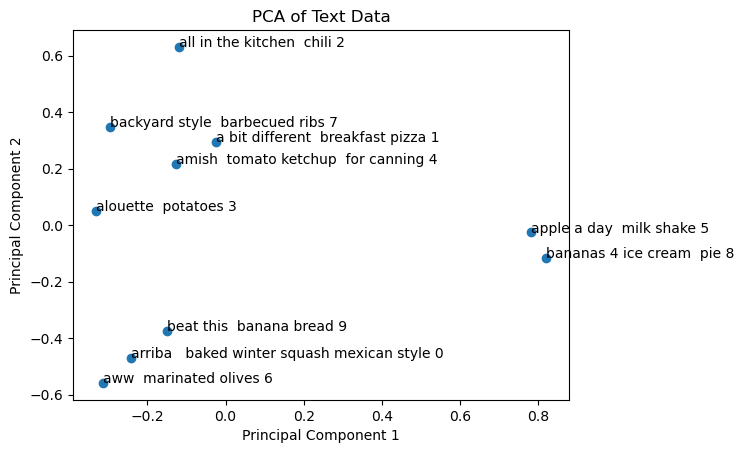

In [14]:

def plot_recipes():
    (X, vectorizer, recipe_list_instances) = get_ingredients_vectorized(10, (1, 2))

    #Here, we convert the text reviews to a set of x y coordinates through dimensionality reduction
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X.toarray())
    x_coordinates = X_pca[:10, 0]
    y_coordinates = X_pca[:10, 1]
    #Plot the PCA components.
    
    plt.scatter(x_coordinates, y_coordinates)
    print(x_coordinates[4], y_coordinates[4])
    plt.title('PCA of Text Data')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    for i in range(0, 10):
        recipe_name = recipes_df.loc[i,'name']
        plt.annotate(f'{recipe_name}' + " " + str(i), (x_coordinates[i], y_coordinates[i]))

plot_recipes()

# Task 2a: Calculate distances.
(15 points)

We're going to compute a dendrogram -- a tree-based visual representation of hierarchical clusters -- on our set of ten recipes. Before we can do that, we need to compute a distance matrix that can be used to return the correct linkage matrix used to create the dendrogram.

For this task, loop through each possible pair of ten points and calculate their distance using the provided `calc_distance` function, to enter into the uncondensed distance matrix we've defined for you. Then, use `squareform()` on the uncondensed matrix to produce a condensed form of distance matrix. (https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.squareform.html)

With this resulting condensed distance matrix, call the `linkage()` function using `method='complete'`. Your function should simply return the results from that linkage() function directly.

Note: In the distance matrix, the distances stored along the diagonal, i.e. measuring the distance between the same points, should be 0. For example, the distance between element 3 and element 3 is zero.

In [15]:
task_id = '2a'

# We've defined a function to calculate euclidean distance between coordinate points.
def calc_distance(x1, x2, y1, y2):
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)


In [16]:
def task_2a_solution():
        #Do not modify this block of code, you'll need it for your solution!
    (X, vectorizer, recipe_list_instances) = get_ingredients_vectorized(10, (1, 2))
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X.toarray())
    x_coordinates = X_pca[:10, 0]
    y_coordinates = X_pca[:10, 1]

    linkage_matrix = None

    uncondensed_distance_matrix = np.zeros((10, 10))

    for i in range(10):
        for j in range(10):
            uncondensed_distance_matrix[i, j] = calc_distance(
                x_coordinates[i], x_coordinates[j],
                y_coordinates[i], y_coordinates[j]
            )

    condensed_distance_matrix = squareform(uncondensed_distance_matrix)
        
    return linkage(condensed_distance_matrix, method='complete')

In [17]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2a_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, np.ndarray
), f"Task {task_id}: Your function should return a np.ndarray. "




del stu_ans

Task 2a - AG tests
Task 2a - your answer:
[[ 5.     8.     0.097  2.   ]
 [ 0.     6.     0.115  2.   ]
 [ 1.     4.     0.128  2.   ]
 [ 9.    11.     0.247  3.   ]
 [ 7.    12.     0.277  3.   ]
 [ 3.    14.     0.393  4.   ]
 [ 2.    15.     0.618  5.   ]
 [13.    16.     1.205  8.   ]
 [10.    17.     1.219 10.   ]]


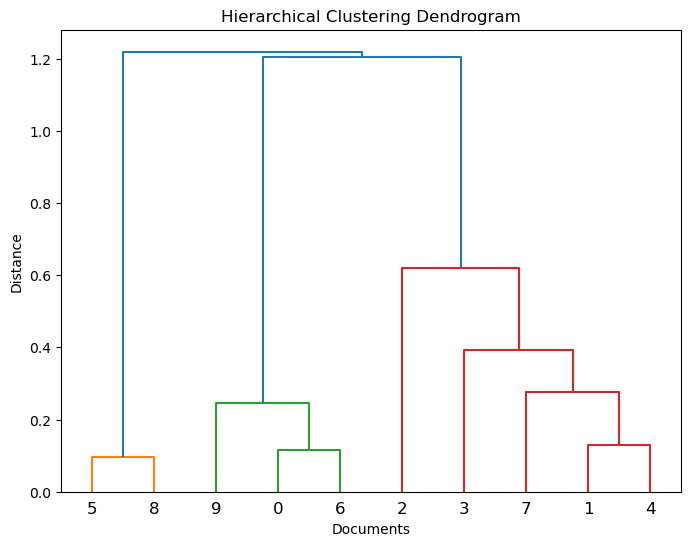

In [18]:
def plot_dendrogram():
    #Step 2: Plot the Dendrogram
    linkage_matrix = task_2a_solution()
    plt.figure(figsize=(8, 6))
    dendrogram(linkage_matrix)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Documents')
    plt.ylabel('Distance')
    plt.show()

plot_dendrogram()

# Task 2b:
(10 Points)

Using the provided `plot_dendrogram` code above with your task 2a solution, you should now have your dendrogram! This shows visually the ingredient similarity relationships among the ten recipes we selected.  The y-axis of the dendrogram shows the distance as computed by the provided distance function.

Now inspect the dendrogram and/or the linkage clustering results and return a list of the pairs of recipes in the dendrogram that have distance between them of less than 0.2. Each pair should be represented using a set (i.e. using `{...}`). These pairs represent very specific clusters of likely very similar foods.  

In [19]:
task_id = '2b'




In [20]:
def task_2b_solution():
    name_series = recipes_df['name']
    sol = []

    pairs = [(5, 8), (0, 6), (1, 4)]
    for a, b in pairs:
        sol.append({name_series[a], name_series[b]})

    return sol

In [21]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2b_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, list
), f"Task {task_id}: Your function should return a list of sets. "




del stu_ans

Task 2b - AG tests
Task 2b - your answer:
[{'bananas 4 ice cream  pie', 'apple a day  milk shake'}, {'arriba   baked winter squash mexican style', 'aww  marinated olives'}, {'amish  tomato ketchup  for canning', 'a bit different  breakfast pizza'}]


# Part 3: Clustering and outlier detection with DBSCAN

Now, for the last question, we're going to have you run DBSCAN on the recipes dataset, and exploit DBSCAN's ability to find outliers to look for unusual recipes that are quite different from typical clusters in the dataset.

# Task 3a: Basic clustering
(10 Points)

We will start by clustering the first hundred recipes in the dataset using the DBSCAN algorithm, and obtaining the cluster assignment of each data point. 

Your solution should (1) create the DBSCAN object, using `eps=0.1` and `min_samples=2`, and then (2) perform clustering and retrieve cluster assignments using as input the data points from the same PCA dimensionality reduction approach used earlier (applied to the first 100 recipes). Step (2) can be done in one line of code. You may find the [DBSCAN documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN.fit_predict) helpful. Take note of the `fit_predict` function.

In [22]:
task_id = '3a'




In [23]:
def task_3a_solution():
    # Vectorize the data using TF-IDF
    (X, vectorizer, recipe_list_instances) = get_ingredients_vectorized(100, (1, 2))
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X.toarray())

    dbscan = None
    cls = None
    # Apply DBSCAN clustering
    dbscan = DBSCAN(eps=0.1, min_samples=2)
    cls = dbscan.fit_predict(X_pca)

    return cls

In [24]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3a_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")


assert isinstance(
    stu_ans, np.ndarray
), f"Task {task_id}: Your function should return a np.ndarray "




del stu_ans

Task 3a - AG tests
Task 3a - your answer:
[ 0  0  0  0  0  0  0  0  0  1  0  2  0  0  0  0  0  0  0  0  0  0  0  1
  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  1  1  0  0  0  0  1
  0  0  1  0  0  3  0  0  1  0  0  3  0  0  0 -1  0  0  0  2  4 -1  0  1
 -1  0  0  0  0  0  0  0  0  0  1  2  0  0  0  0  0  0  1  0  0  0  0  1
  4  0 -1  0]


# Task 3b: Outlier detection
(10 points)

Now that you have the cluster assignments for the 100 recipes, what does DBSCAN estimate are the outlier recipes (if any)?

Hint(s):
- The outlier data points will have -1 for their cluster assignment.
- np.where is useful for this question to find the indices of the outlier entries
- When you obtain the indices of the outliers, access recipes_df to obtain the name of each corresponding recipe. 
- Return the names of the outlier recipe(s) as a list

In [25]:
task_id = '3b'




In [26]:
def task_3b_solution():
    cls = task_3a_solution()

    outlier_indices = np.where(cls == -1)[0]
    return [recipes_df.loc[i, 'name'] for i in outlier_indices]

In [27]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3b_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, list
), f"Task {task_id}: Your function should return a list of lists "




del stu_ans

Task 3b - AG tests
Task 3b - your answer:
['more  more    apple pear jigglers', 'now and later  vegetarian empanadas', 'one pot  brownies', 'the man s  taco dip']


Run the code below to visualize the clusters and outliers found by DBSCAN for this recipe sample. You can see the outliers plotted as the 'noise' category (yellow points). 

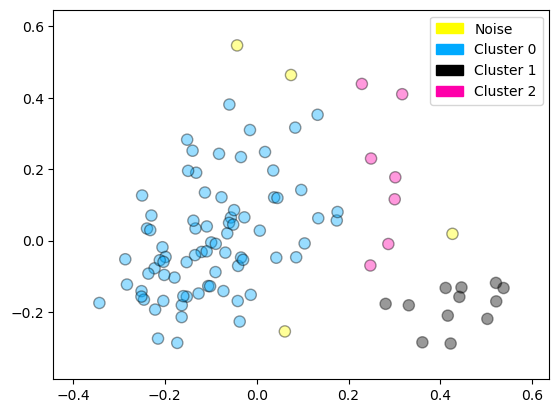

<Figure size 640x480 with 0 Axes>

In [28]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def plot_labelled_scatter(X, y, class_labels):
    num_labels = len(class_labels)

    buffer = 0.1
    x_min, x_max = X[:, 0].min() - buffer, X[:, 0].max() + buffer
    y_min, y_max = X[:, 1].min() - buffer, X[:, 1].max() + buffer

    marker_array = ['o', '^', '*']
    color_array = ['#FFFF00', '#00AAFF', '#000000', '#FF00AA']
    cmap_bold = ListedColormap(color_array)
    bnorm = BoundaryNorm(np.arange(0, num_labels + 1, 1), ncolors=num_labels)
    plt.figure()

    plt.scatter(X[:, 0], X[:, 1], s=65, c=y, cmap=cmap_bold, norm = bnorm, alpha = 0.40, edgecolor='black', lw = 1)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    h = []
    for c in range(0, num_labels):
        h.append(mpatches.Patch(color=color_array[c], label=class_labels[c]))
    plt.legend(handles=h)

    plt.show()



def plot_dbscan():
    # Vectorize the data using TF-IDF
    (X, vectorizer, recipe_list_instances) = get_ingredients_vectorized(100, (1, 2))
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X.toarray())
    cls = task_3a_solution()
    plot_labelled_scatter(X_pca, cls + 1, ["Noise", "Cluster 0", "Cluster 1", "Cluster 2"])
    plt.tight_layout()
    
plot_dbscan()

In [29]:
"""clustering on text vector vs nutritional content"""
from sklearn.preprocessing import StandardScaler


def get_PCA():
    numerical_fields = ['calories','total_fat_pdv','sugar_pdv','sodium_pdv','protein_pdv','saturated_fat_pdv','carbs_pdv']
    numerical_df = recipes_df[numerical_fields].iloc[:100, :]
    normalized_data = StandardScaler().fit_transform(numerical_df)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(normalized_data)
    return X_pca
    
    # Apply DBSCAN clustering

    

# Task 3c: Cluster analysis using nutritional features instead of text
(10 points)

So far, we've been looking at the *text* of recipe ingredients when making clusters. Let's change things up by using nutritional information instead and re-running DBSCAN with this new recipe representation. 

Your solution should start by running the above new version of `get_PCA` that recomputes PCA using the numeric nutrition variables. With this new `X_pca` input, run DBSCAN again but this time, set `eps=1`, and then just you did in task 3a, return the cluster assignments you obtain.

In [30]:
task_id = '3c'




In [31]:
def task_3c_solution():

    X_pca = get_PCA()
    dbscan = None
    cls = None

    dbscan = DBSCAN(eps=1, min_samples=2)
    cls = dbscan.fit_predict(X_pca)

    return cls

In [32]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3c_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")


assert isinstance(
    stu_ans, np.ndarray
), f"Task {task_id}: Your function should return a ndarray. "




del stu_ans

Task 3c - AG tests
Task 3c - your answer:
[ 0  0  0  0  0  0  0 -1 -1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  2
  2  0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  3 -1
  0  0  0  0  0  0  3  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  2  0  0  0  0  0  0  3  0  0  0  0  0  0  0  3  0  0  1  0  0  0 -1  0
 -1  0  0  0]


Run the code below; The nutritional information paints a very different picture!

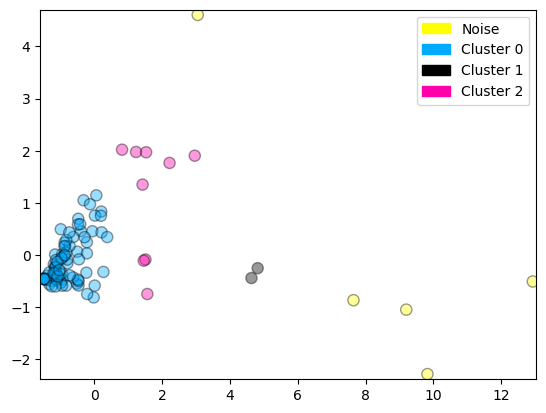

<Figure size 640x480 with 0 Axes>

In [33]:
def plot_dbscan():
    # Vectorize the data using TF-IDF
    X_pca = get_PCA()
    cls = task_3c_solution()
    plot_labelled_scatter(X_pca, cls + 1, ["Noise", "Cluster 0", "Cluster 1", "Cluster 2"])
    plt.tight_layout()
    
plot_dbscan()

# Task 3d: Finding nutritional outliers
(10 points)

Now, based on the nutritional information, which recipes are outliers?

The code here is the same as your 3b solution, but uses the DBSCAN output from task 3c as input instead.

In [34]:
task_id = '3d'




In [35]:
def task_3d_solution():

    cls = task_3c_solution()

    outlier_indices = np.where(cls == -1)[0]
    return [recipes_df.loc[i, 'name'] for i in outlier_indices]

In [36]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3d_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, list
), f"Task {task_id}: Your function should return a ndarray. "




del stu_ans

Task 3d - AG tests
Task 3d - your answer:
['backyard style  barbecued ribs', 'bananas 4 ice cream  pie', 'jeanne s style  birthday cake', 'symphony  brownies', 'the best  chocolate chip cheesecake ever']
